In [1]:
# Import libraries
import pickle
import numpy as np
import anndata as ad
import pandas as pd
import scanpy as sc
import scipy
import scipy.sparse as sp 
import matplotlib.pyplot as plt
import anndata
from anndata import AnnData

# For plotting
import seaborn as sns

# For PCA
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# For umap
import umap

# SCVI
import scvi
import cellxgene_census
import cellxgene_census.experimental

# For ML training
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from scipy.stats import pearsonr
from scipy.sparse import issparse, vstack

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

# For NNLS
from scipy.optimize import nnls

/nfs/sw/easybuild/software/custom-conda/geneformer-1.0/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/nfs/home/aoku/.local/lib/python3.10/site-packages/docrep/decorators.py:43: SyntaxWarning: 'param_categorical_covariate_keys' is not a valid key!
  doc = func(self, args[0].__doc__, *args[1:], **kwargs)


# Define plotting functions

In [2]:
def plot_true_vs_predicted(y_test_df, predicted_proportions, n_cols=4, figsize_per_plot=(3, 3), dot_size=5, save=False, title=""):

    # Get column names (cell types or lineages)
    cols = predicted_proportions.columns
    n_rows = int(np.ceil(len(cols) / n_cols))

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * figsize_per_plot[0], n_rows * figsize_per_plot[1]))
    axes = axes.flatten()

    for i, col in enumerate(cols):
        ax = axes[i]
        x = y_test_df[col]
        y = predicted_proportions[col]

        # Scatterplot
        sns.scatterplot(x=x, y=y, alpha=0.7, ax=ax, s=dot_size)

        # Identity line
        min_val = min(x.min(), y.min())
        max_val = max(x.max(), y.max())
        ax.plot([min_val, max_val], [min_val, max_val], 'r--')

        # Correlation coefficient
        corr, _ = pearsonr(x, y)
        ax.text(
            0.05, 0.95, f"r = {corr:.2f}",
            transform=ax.transAxes,
            verticalalignment='top',
            fontsize=9,
            bbox=dict(boxstyle="round", facecolor="white", alpha=0.5)
        )

        # Titles and labels
        ax.set_title(f'{col}')
        ax.set_xlabel('True')
        ax.set_ylabel('Predicted')

    # Hide any unused subplots
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()

    if save:
        plt.savefig(f"{title}_plot.png", dpi=300, bbox_inches="tight")
    plt.show()


In [3]:
#sample_labels = ['B2-CZI08N'] * 1000 + ['B3-CZI11N'] * 1000 + ['B3-CZI05N'] * 1000 + ['test = B15-CZI251N'] * 1000
sample_labels = ['Sample 1'] * 1000 + ['Sample 2'] * 1000 + ['Sample 3'] * 1000 + ['Test = Sample 4'] * 1000

def plot_pca(train_df, test_df, sample_labels, n_components=2, title = "", dpi=300, save_path=""):

    # Add 'source' column
    train_df = train_df.copy()
    train_df['source'] = 'train'

    test_df = test_df.copy()
    test_df['source'] = 'test'

    # Merge train and test
    merged_df = pd.concat([train_df, test_df], ignore_index=True)

    # Assign sample labels
    if len(sample_labels) != merged_df.shape[0]:
        raise ValueError("Length of sample_labels must equal number of rows in merged_df")
    merged_df['sample'] = sample_labels

    # PCA input (exclude metadata)
    X = merged_df.drop(['source', 'sample'], axis=1)

    # PCA computation
    pca = PCA(n_components=n_components)
    principal_components = pca.fit_transform(X)

    # Create PCA DataFrame
    pca_df = pd.DataFrame(
        data=principal_components,
        columns=[f'PC{i+1}' for i in range(n_components)]
    )
    pca_df['sample'] = merged_df['sample']

    # Plot
    plt.figure(figsize=(6, 6))
    for sample in pca_df['sample'].unique():
        subset = pca_df[pca_df['sample'] == sample]
        plt.scatter(
            subset['PC1'],
            subset['PC2'],
            label=sample,
            alpha=0.7
        )

    plt.xlabel(f'PC 1 ({pca.explained_variance_ratio_[0]*100:.2f}%)', fontsize=16)
    plt.ylabel(f'PC 2 ({pca.explained_variance_ratio_[1]*100:.2f}%)', fontsize=16)
    #plt.title(title)
    #plt.legend()
    plt.legend(handlelength=0, frameon=False)
    plt.gca().spines['top'].set_visible(False)
    plt.gca().spines['right'].set_visible(False)
    plt.grid(False)
    plt.tight_layout()
    plt.savefig(save_path, dpi=dpi, bbox_inches="tight")
    plt.show()

In [4]:
def run_rf_training(X, y, test, title=""):
    """
    Train RandomForestRegressor on training split, evaluate on test split,
    and predict on scvi_latent_czi_pseudobulk_test. Plots true vs predicted 
    correlations for both sets.

    Parameters
    ----------
    X : pd.DataFrame
        Latent feature representation (e.g., scVI pseudobulk embeddings).
    y : pd.DataFrame
        Corresponding cell proportions for samples.
    """

    # Split data into train/test
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    # Train RF model
    model_rf = RandomForestRegressor(
        max_depth=20,
        max_features="sqrt",
        min_samples_leaf=1,
        min_samples_split=2,
        n_estimators=500,
        random_state=42
    )
    model_rf.fit(X_train, y_train)

    # Predict on held-out test set
    y_pred = model_rf.predict(X_test)
    predicted_proportions = pd.DataFrame(
        y_pred, columns=y_test.columns, index=X_test.index
    )

    # Plot correlation (pearson)
    plot_true_vs_predicted(y_test, predicted_proportions)

    # Predict on external test set (predefined globals)
    y_pred_test = model_rf.predict(test)
    predicted_proportions_test = pd.DataFrame(
        y_pred_test, columns=y_train.columns,
    )

    plot_true_vs_predicted(test_czi_cell_prop, predicted_proportions_test,save=True, title=title)

    return predicted_proportions, predicted_proportions_test

In [5]:
# def save_pca_plot(train_df, test_df, sample_labels, title="", save_path=None, dpi=300):
#     # Concatenate train + test
#     combined = pd.concat([train_df, test_df], axis=0)
    
#     # PCA
#     pca = PCA(n_components=2)
#     pca_result = pca.fit_transform(combined)
    
#     # Plot
#     plt.figure(figsize=(8, 6))
#     scatter = plt.scatter(pca_result[:, 0], pca_result[:, 1],
#                           c=sample_labels, cmap="tab10", alpha=0.7, edgecolor="k")
#     plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.2f}% var)")
#     plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.2f}% var)")
#     plt.title(title)
#     plt.colorbar(scatter, label="Sample Labels")
#     plt.tight_layout()
    
#     if save_path:
#         plt.savefig(save_path, dpi=dpi, bbox_inches="tight")
#         print(f"Saved PCA plot to {save_path} (dpi={dpi})")
#     else:
#         plt.show()

In [6]:
def evaluate_predictions(y_true_df, y_pred_df):
    """
    Compute MAE, MSE, and RMSE per column between true and predicted values.

    Parameters
    ----------
    y_true_df : pd.DataFrame
        Ground truth cell proportions (rows = samples, cols = cell types).
    y_pred_df : pd.DataFrame
        Predicted cell proportions with same shape as y_true_df.

    Returns
    -------
    results_df : pd.DataFrame
        DataFrame containing per-cell-type MAE, MSE, and RMSE.
    """
    results = []
    for col in y_true_df.columns:
        y_true = y_true_df[col]
        y_pred = y_pred_df[col]

        mae = mean_absolute_error(y_true, y_pred)
        mse = mean_squared_error(y_true, y_pred)
        rmse = np.sqrt(mse)

        results.append({"Cell_Type": col, "MAE": mae, "MSE": mse, "RMSE": rmse})

    return pd.DataFrame(results)

In [7]:
def evaluate_overall_error(y_true_df, y_pred_df):
    """
    Compute overall MAE, MSE, and RMSE between true and predicted values.

    Parameters
    ----------
    y_true_df : pd.DataFrame
        Ground truth values (rows = samples, cols = features/cell types).
    y_pred_df : pd.DataFrame
        Predicted values with same shape/columns as y_true_df.

    Returns
    -------
    metrics : dict
        Dictionary containing MAE, MSE, RMSE.
    """
    y_true = y_true_df[y_pred_df.columns]

    mae = mean_absolute_error(y_true, y_pred_df)
    mse = mean_squared_error(y_true, y_pred_df)
    rmse = np.sqrt(mse)

    metrics = {"MAE": mae, "MSE": mse, "RMSE": rmse}

    return metrics

In [8]:
# Function to get NNLS
def estimate_proportions(bulk_df, signature_matrix):
    """
    Estimate cell type proportions in bulk samples via NNLS.
    
    Parameters
    ----------
    bulk_df : pd.DataFrame
        Bulk expression (genes x samples).
    signature_matrix : pd.DataFrame
        Signature matrix (genes x cell types).
    
    Returns
    -------
    pd.DataFrame
        Proportions (samples x cell types).
    """
    # Keep only common genes
    common_genes = bulk_df.index.intersection(signature_matrix.index)
    bulk = bulk_df.loc[common_genes]
    sig = signature_matrix.loc[common_genes]

    props = []
    for sample in bulk.columns:
        y = bulk[sample].values
        x = sig.values
        coeffs, _ = nnls(x, y)  # non-negative least squares
        coeffs = coeffs / coeffs.sum()  # normalize to proportions
        props.append(coeffs)

    props_df = pd.DataFrame(props, index=bulk.columns, columns=sig.columns)
    return props_df

In [9]:
# Read cell type proportions (should be the same for both scVi and geneformer)
test_czi_cell_prop = pd.read_csv("/gpfs/commons/groups/compbio/projects/ao_projects/ml_deconv_data/test_pseudobulk_cell_prop.csv")
pseudobulk_czi_cell_prop = pd.read_csv("/gpfs/commons/groups/compbio/projects/ao_projects/ml_deconv_data/train_pseudobulk_cell_prop.csv")

## scVI pre-trained on cxg

In [10]:
# Read scVI latent variables
scvi_latent_czi_pseudobulk = pd.read_csv("/gpfs/commons/groups/compbio/projects/ao_projects/ml_deconv_data/scVI_embed_train_set.csv", index_col=0)
scvi_latent_czi_pseudobulk_test = pd.read_csv("/gpfs/commons/groups/compbio/projects/ao_projects/ml_deconv_data/scVI_embed_test_set.csv", index_col=0)

In [11]:
sig_matrix = pd.read_csv("/gpfs/commons/groups/compbio/projects/ao_projects/ml_deconv_data/scVI_signature_matrix_from_pseudobulk.csv", index_col=0)
#sig_matrix = pd.read_csv("/gpfs/commons/groups/compbio/projects/ao_projects/ml_deconv_data/scVI_signature_matrix.csv", index_col=0)
sig_matrix = sig_matrix.T

# add "scVI" to index names
sig_matrix.index = ["scVI_" + str(i) for i in sig_matrix.index]

In [12]:
# Transpose pseudobulk to match signature matrix 
scvi_latent_czi_pseudobulk_test_T = scvi_latent_czi_pseudobulk_test.copy().T

# add "scVI" to index names
scvi_latent_czi_pseudobulk_test_T.index = ["scVI_" + str(i) for i in scvi_latent_czi_pseudobulk_test_T.index]

In [13]:
nnls_scvi = estimate_proportions(bulk_df = scvi_latent_czi_pseudobulk_test_T, signature_matrix = sig_matrix)

In [15]:
nnls_scvi

id,Endothelial,Epithelial,Immune,Mesenchymal
0,0.206586,0.314300,0.479114,0.0
1,0.334932,0.294213,0.370855,0.0
2,0.295936,0.399786,0.304278,0.0
3,0.117575,0.279037,0.603388,0.0
4,0.227801,0.361008,0.411191,0.0
...,...,...,...,...
995,0.120095,0.337908,0.541998,0.0
996,0.220022,0.345611,0.434367,0.0
997,0.235550,0.306650,0.457800,0.0
998,0.346256,0.244495,0.409249,0.0


/tmp/ipykernel_2514593/1109380411.py:24: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, _ = pearsonr(x, y)


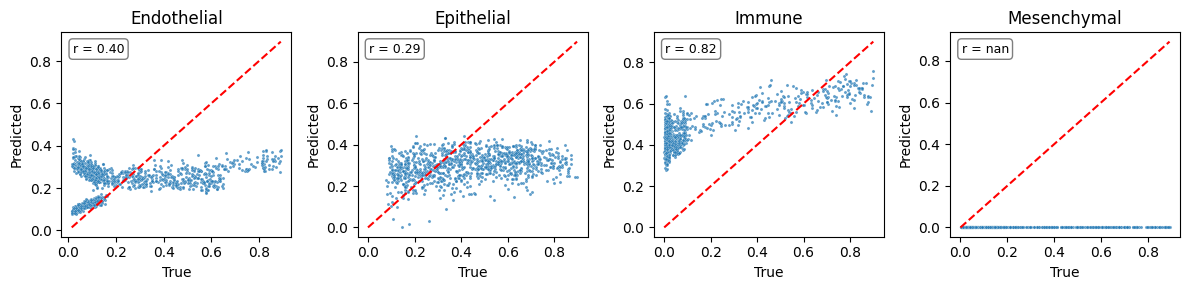

In [14]:
plot_true_vs_predicted(y_test_df=test_czi_cell_prop, predicted_proportions=nnls_scvi)

In [27]:
evaluate_predictions(y_true_df=test_czi_cell_prop, y_pred_df = nnls_scvi)

,Cell_Type,MAE,MSE,RMSE
0,Epithelial,0.195961,0.059441,0.243804
1,Endothelial,0.169196,0.046958,0.216698
2,Mesenchymal,0.152633,0.071595,0.267572
3,Immune,0.339823,0.130527,0.361286


In [28]:
evaluate_overall_error(y_true_df=test_czi_cell_prop, y_pred_df = nnls_scvi)

{'MAE': 0.2144030058812159,
 'MSE': 0.07713020888512534,
 'RMSE': 0.2777232595320841}

## Trained scVI - 500 embed

In [16]:
# Read scVI latent variables
scvi_500 = pd.read_csv("/gpfs/commons/groups/compbio/projects/ao_projects/ml_deconv_data/scVI_with_batch_corr_dim_500_train_set.csv")
scVI_test_500 = pd.read_csv("/gpfs/commons/groups/compbio/projects/ao_projects/ml_deconv_data/scVI_with_batch_corr_dim_500_test_set.csv")

In [17]:
sig_matrix = pd.read_csv("/gpfs/commons/groups/compbio/projects/ao_projects/ml_deconv_data/sig_mat_scVI_model_500_n_dim_with_batch_correction.csv", index_col=0)
#sig_matrix = pd.read_csv("/gpfs/commons/groups/compbio/projects/ao_projects/ml_deconv_data/scVI_signature_matrix.csv", index_col=0)
sig_matrix = sig_matrix.T

# add "scVI" to index names
sig_matrix.index = ["scVI_" + str(i) for i in sig_matrix.index]

In [18]:
sig_matrix.head()

,Endothelial,Epithelial,Immune,Mesenchymal
scVI_0,0.012383,0.011627,0.041323,0.022365
scVI_1,0.020961,0.008470,-0.026644,-0.032836
scVI_2,0.036428,0.008212,0.012093,0.013182
scVI_3,0.865228,0.785769,0.894445,0.483785
scVI_4,-0.018799,-0.010017,0.032996,-0.020605


In [19]:
# Transpose pseudobulk to match signature matrix 
scVI_test_500_T = scVI_test_500.copy().T

# add "scVI" to index names
scVI_test_500_T.index = ["scVI_" + str(i) for i in scVI_test_500_T.index]

In [20]:
scVI_test_500_T.head()

,0,1,2,3,4,5,6,7,8,9,...,990,991,992,993,994,995,996,997,998,999
scVI_0,0.195105,0.229294,0.148482,-0.006896,0.202981,0.165803,0.185244,-0.047221,0.180953,0.231625,...,0.177326,-0.012195,0.185030,0.233378,0.215925,0.123052,0.135070,0.164255,0.148169,0.043053
scVI_1,-0.735117,-0.504020,-0.794991,-0.908982,-0.684934,-0.814311,-0.874373,-0.853311,-0.796307,-0.610685,...,-0.781511,-0.875786,-0.694775,-0.677528,-0.867362,-0.896076,-0.870590,-0.799666,-0.744049,-0.911403
scVI_2,-1.341923,-0.970512,-1.320438,-1.554389,-1.308168,-1.278755,-1.341066,-1.460380,-1.321659,-1.056837,...,-1.313555,-1.495004,-1.304693,-1.139160,-1.319626,-1.472390,-1.265093,-1.270261,-1.274650,-1.543555
scVI_3,6.298971,7.521566,2.990619,5.120700,6.501710,6.244157,4.720956,5.814681,5.464944,6.386731,...,3.842908,5.050564,6.216288,6.614588,4.280096,5.425661,4.929538,6.176259,3.343913,5.814119
scVI_4,0.420257,0.162305,0.407011,0.669094,0.441990,0.437375,0.490718,0.654637,0.465105,0.230270,...,0.406156,0.662625,0.443795,0.297309,0.473418,0.549465,0.478802,0.423027,0.361189,0.629701


In [21]:
nnls_scvi = estimate_proportions(bulk_df = scVI_test_500_T, signature_matrix = sig_matrix)

In [22]:
nnls_scvi.head()

,Endothelial,Epithelial,Immune,Mesenchymal
0,0.0,0.0,1.0,0.0
1,0.0,0.0,1.0,0.0
2,0.0,0.0,1.0,0.0
3,0.0,0.0,1.0,0.0
4,0.0,0.0,1.0,0.0


/tmp/ipykernel_2514593/1109380411.py:24: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, _ = pearsonr(x, y)
/tmp/ipykernel_2514593/1109380411.py:24: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, _ = pearsonr(x, y)
/tmp/ipykernel_2514593/1109380411.py:24: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, _ = pearsonr(x, y)
/tmp/ipykernel_2514593/1109380411.py:24: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, _ = pearsonr(x, y)


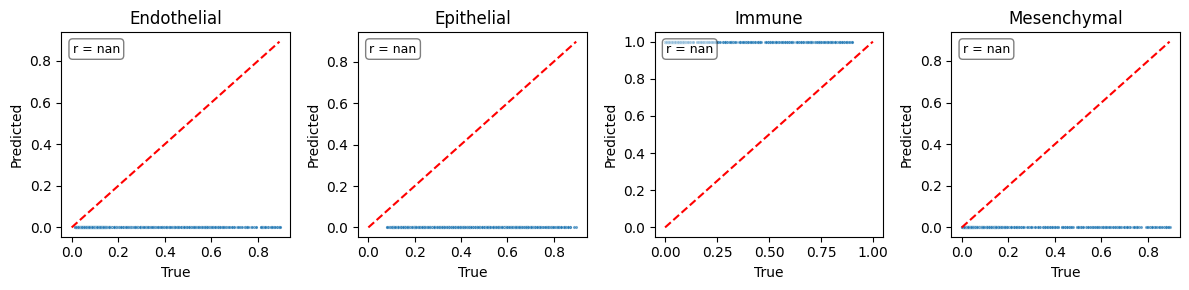

In [23]:
plot_true_vs_predicted(y_test_df=test_czi_cell_prop, predicted_proportions=nnls_scvi)

In [18]:
evaluate_overall_error(y_true_df=test_czi_cell_prop, y_pred_df = nnls_scvi)

{'MAE': 0.42556, 'MSE': 0.30346165937499997, 'RMSE': 0.5508735420901969}

### Zero-shot Geneformer model

In [10]:
# Read scVI latent variables
gf_zero = pd.read_csv("/gpfs/commons/groups/compbio/projects/ao_projects/ml_deconv_data/train/gf_pseudobulk_train_set.csv", index_col=0)
gf_test_zero = pd.read_csv("/gpfs/commons/groups/compbio/projects/ao_projects/ml_deconv_data/test/gf_pseudobulk_test_set.csv", index_col=0)

In [11]:
sig_matrix = pd.read_csv("/gpfs/commons/groups/compbio/projects/ao_projects/ml_deconv_data/geneformer_signature_matrix_from_pseudobulk.csv", index_col=0)
sig_matrix = sig_matrix.T

sig_matrix = sig_matrix.rename_axis(None, axis=1)

sig_matrix.index = ["gf_" + str(i) for i in sig_matrix.index]

In [12]:
sig_matrix.shape

(1152, 4)

In [13]:
gf_test_zero.reset_index(drop=True, inplace=True)

gf_test_zero_T = gf_test_zero.T

gf_test_zero_T.index = ["gf_" + str(i) for i in gf_test_zero_T.index]

In [14]:
nnls_gf = estimate_proportions(bulk_df = gf_test_zero_T, signature_matrix = sig_matrix)

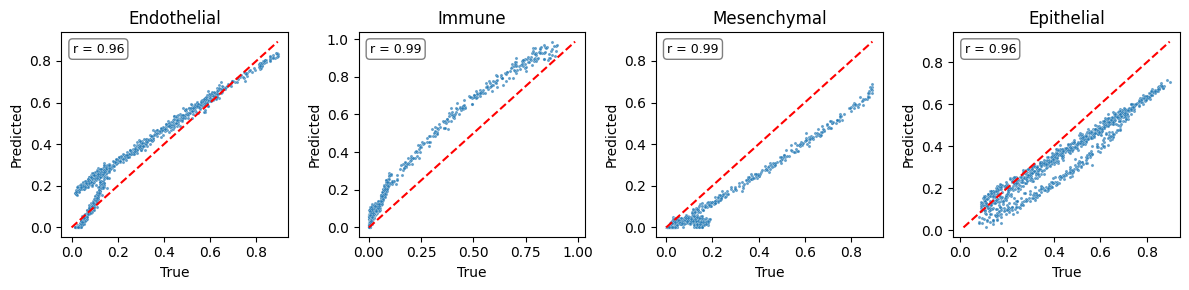

In [23]:
plot_true_vs_predicted(y_test_df=test_czi_cell_prop, predicted_proportions=nnls_gf[["Endothelial", "Immune", "Mesenchymal", "Epithelial"]], save=True, title="gf_zero_nnls")

In [69]:
evaluate_overall_error(y_true_df=test_czi_cell_prop, y_pred_df = nnls_gf)

{'MAE': 0.08138029465674168,
 'MSE': 0.010239721942574566,
 'RMSE': 0.1011915112179602}

### Finetuned Geneformer model

In [110]:
# Read scVI latent variables
gf_finetuned = pd.read_csv("/gpfs/commons/groups/compbio/projects/ao_projects/ml_deconv_data/train/gf_finetuned_pseudobulk_train_set.csv", index_col=0)
gf_test_finetuned = pd.read_csv("/gpfs/commons/groups/compbio/projects/ao_projects/ml_deconv_data/test/gf_finetuned_pseudobulk_test_set.csv", index_col=0)

In [71]:
sig_matrix = pd.read_csv("/gpfs/commons/groups/compbio/projects/ao_projects/ml_deconv_data/geneformer_finetuned_signature_matrix_from_pseudobulk.csv", index_col=0)
sig_matrix = sig_matrix.T

sig_matrix = sig_matrix.rename_axis(None, axis=1)

sig_matrix.index = ["gf_" + str(i) for i in sig_matrix.index]

In [73]:
gf_test_finetuned.reset_index(drop=True, inplace=True)

gf_test_finetuned_T = gf_test_finetuned.T

gf_test_finetuned_T.index = ["gf_" + str(i) for i in gf_test_finetuned_T.index]

In [77]:
nnls_gf = estimate_proportions(bulk_df = gf_test_finetuned_T, signature_matrix = sig_matrix)

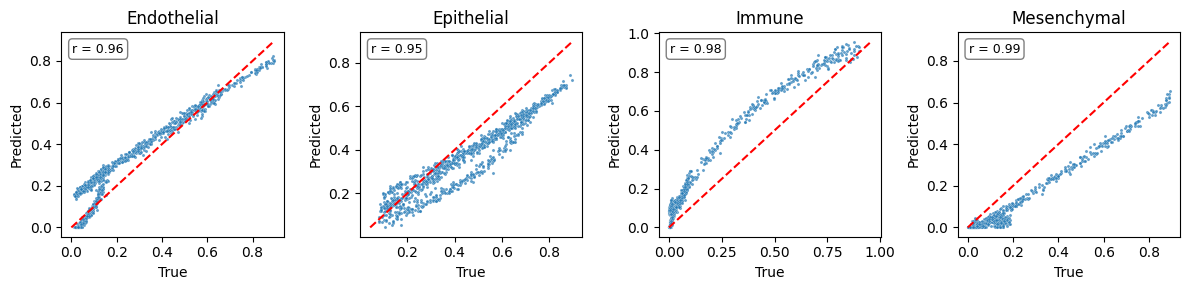

In [78]:
plot_true_vs_predicted(y_test_df=test_czi_cell_prop, predicted_proportions=nnls_gf)

In [80]:
evaluate_overall_error(y_true_df=test_czi_cell_prop, y_pred_df = nnls_gf)

{'MAE': 0.08195894861246833,
 'MSE': 0.010422072423526363,
 'RMSE': 0.10208855187300074}

### Geneformer model - more samples

In [10]:
# Read scVI latent variables
gf_plus = pd.read_csv("/gpfs/commons/groups/compbio/projects/ao_projects/ml_deconv_data/train/gf_zeroshot_plus_pseudobulk_train_set.csv", index_col=0)
gf_test_zero = pd.read_csv("/gpfs/commons/groups/compbio/projects/ao_projects/ml_deconv_data/test/gf_pseudobulk_test_set.csv", index_col=0)

### PCA 

In [132]:
# Read in pseudbulks transform using PCA
test_pseudobulk_czi = pd.read_csv("/gpfs/commons/groups/compbio/projects/ao_projects/ml_deconv_data/pseudobulk_test_set.csv")

In [133]:
test_pseudobulk_czi.head()

,ENSG00000243485,ENSG00000237613,ENSG00000186092,ENSG00000238009,ENSG00000239945,ENSG00000239906,ENSG00000241860,ENSG00000241599,ENSG00000286448,ENSG00000236601,...,ENSG00000274175,ENSG00000275869,ENSG00000273554,ENSG00000278782,ENSG00000277761,ENSG00000277836,ENSG00000278633,ENSG00000276017,ENSG00000278817,ENSG00000277196
0,0.0,0.0,1.0,9.0,0.0,0.0,11.0,4.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
1,0.0,0.0,0.0,6.0,0.0,0.0,11.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,0.0
2,0.0,0.0,0.0,4.0,0.0,0.0,21.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,7.0,0.0,1.0,0.0
3,0.0,0.0,0.0,31.0,0.0,0.0,9.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,1.0,8.0,0.0,0.0,8.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,2.0,0.0


In [134]:
sig_matrix_gex = pd.read_csv("/gpfs/commons/groups/compbio/projects/ao_projects/ml_deconv_data/gex_signature_matrix.csv", index_col=0)

In [135]:
shared_cols = sig_matrix_gex.T.columns.intersection(test_pseudobulk_czi.columns)

sig_matrix_gex = sig_matrix_gex.T[shared_cols]

In [136]:
test_pseudobulk_czi = test_pseudobulk_czi.loc[:, shared_cols]

In [137]:
test_pseudobulk_czi.shape

(1000, 36591)

In [19]:
pd.Series(sig_matrix_gex.columns.isin(test_pseudobulk_czi.columns)).value_counts()

True    36591
Name: count, dtype: int64

In [20]:
sig_matrix_bulk_concat = pd.concat([test_pseudobulk_czi, sig_matrix_gex], ignore_index=False)

In [21]:
sig_matrix_bulk_concat.tail()

,ENSG00000243485,ENSG00000237613,ENSG00000186092,ENSG00000238009,ENSG00000239945,ENSG00000239906,ENSG00000241860,ENSG00000241599,ENSG00000286448,ENSG00000236601,...,ENSG00000274175,ENSG00000275869,ENSG00000273554,ENSG00000278782,ENSG00000277761,ENSG00000277836,ENSG00000278633,ENSG00000276017,ENSG00000278817,ENSG00000277196
999,0.0,0.0,0.000000,19.000000,0.000000,0.0,20.000000,1.00000,0.00000,0.0,...,0.0,0.0,0.000000,0.00000,0.00000,0.0,0.000000,0.000000,0.000000,0.000000
Endothelial,0.0,0.0,0.000000,0.003576,0.000275,0.0,0.004677,0.00000,0.00000,0.0,...,0.0,0.0,0.000275,0.00000,0.00000,0.0,0.000275,0.000000,0.000825,0.000000
Epithelial,0.0,0.0,0.000461,0.008758,0.000000,0.0,0.030422,0.00507,0.00000,0.0,...,0.0,0.0,0.000000,0.00000,0.00000,0.0,0.000230,0.000230,0.000230,0.000000
Immune,0.0,0.0,0.000000,0.002045,0.002045,0.0,0.014315,0.00409,0.00000,0.0,...,0.0,0.0,0.000000,0.00000,0.00000,0.0,0.000000,0.002045,0.000000,0.000000
Mesenchymal,0.0,0.0,0.000210,0.003146,0.000000,0.0,0.005453,0.00000,0.00021,0.0,...,0.0,0.0,0.000839,0.00021,0.00021,0.0,0.000839,0.000839,0.001678,0.000839


In [32]:
# Standardize the data
scaler = StandardScaler()
sig_matrix_bulk_concat_scaled = pd.DataFrame(scaler.fit_transform(sig_matrix_bulk_concat.copy()))

# Run PCA
pca = PCA(n_components=10) 
pca_merged = pca.fit_transform(sig_matrix_bulk_concat_scaled)

In [33]:
# transform to dataframe
pca_merged = pd.DataFrame(pca_merged)

In [34]:
# add "PC" to index names
pca_merged.columns = ["PC_" + str(i) for i in range(0, pca_merged.shape[1])]

In [35]:
# Sig Matrix 
sig_mat_pca = pca_merged.iloc[-4:,:]
sig_mat_pca.index = sig_matrix_bulk_concat.iloc[-4:,:].index
sig_mat_pca = sig_mat_pca.T

In [36]:
pca_merged.iloc[0:1000, :].head()

,PC_0,PC_1,PC_2,PC_3,PC_4,PC_5,PC_6,PC_7,PC_8,PC_9
0,-30.507262,20.798710,-36.002396,-0.833684,-0.268036,2.016756,2.539083,-4.959663,-10.264771,-8.340055
1,-55.489885,48.932927,-146.811071,-17.700757,0.322715,-1.535763,-1.344249,-1.698960,-4.266818,2.372740
2,-111.854347,-124.340442,31.104897,-40.210185,1.107338,-5.856057,-5.707681,1.063423,-0.978987,9.211986
3,161.356409,-32.408618,3.811707,0.861617,0.168520,-1.326375,-1.657319,-2.175198,1.026610,22.844064
4,-30.678332,6.107003,-76.704007,-15.899638,0.385266,-2.073942,-2.131712,6.221008,14.230385,-9.327742


In [46]:
nnls_pca = estimate_proportions(bulk_df = pca_merged.iloc[0:1000, :].T, signature_matrix = sig_mat_pca)

In [39]:
nnls_pca.head()
#test_czi_cell_prop.head()

,Endothelial,Epithelial,Immune,Mesenchymal
0,0.256404,0.058301,0.618530,0.066764
1,0.257782,0.068541,0.596012,0.077665
2,0.254366,0.099148,0.540653,0.105833
3,NaN,NaN,NaN,NaN
4,0.257733,0.063807,0.605694,0.072766


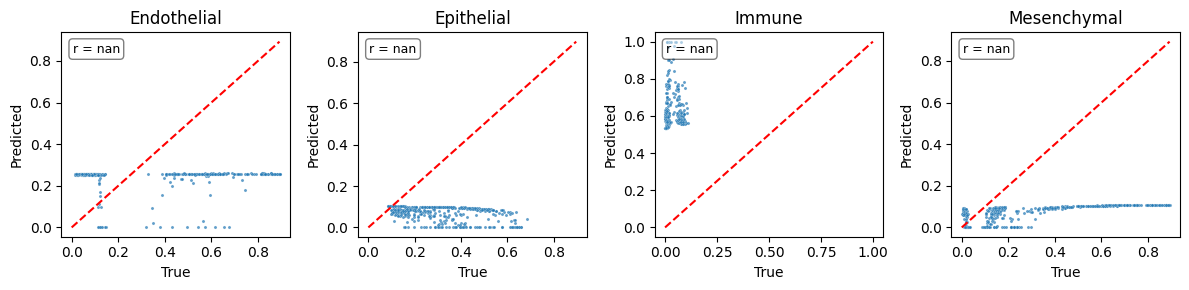

In [40]:
plot_true_vs_predicted(y_test_df=test_czi_cell_prop, predicted_proportions=nnls_pca)

In [221]:
evaluate_overall_error(y_true_df=test_czi_cell_prop, y_pred_df = nnls_pca)

### PCA version 2

In [113]:
test_pseudobulk_czi.shape

(1000, 36591)

In [114]:
sig_matrix_gex.shape

(4, 36591)

In [115]:
# Step 1: Standardize gene expression (genes are rows, scale across samples)
scaler = StandardScaler()

bulk_scaled = pd.DataFrame(
    scaler.fit_transform(test_pseudobulk_czi))

sig_scaled = pd.DataFrame(
    scaler.transform(sig_matrix_gex))

In [116]:
sig_scaled.shape

(4, 36591)

In [125]:
# Step 2: Fit PCA only on *gene space* (bulk)
pca = PCA(n_components=10)
pca.fit(bulk_scaled) 

PCA(n_components=10)

In [126]:
# Step 3: Project bulk and signatures into the same PCA space
bulk_pca = pd.DataFrame(
    pca.transform(bulk_scaled),
    columns=[f"PC_{i}" for i in range(10)]
).T   # PCs x samples

In [127]:
bulk_pca.head()

,0,1,2,3,4,5,6,7,8,9,...,990,991,992,993,994,995,996,997,998,999
PC_0,-32.112339,-57.710082,-112.024509,163.880781,-31.913049,-18.520959,-28.307185,224.591228,-20.895079,-47.434854,...,-122.337603,168.149521,-30.571934,-35.393929,-67.545014,35.079704,-14.820013,-22.377656,-144.091485,130.840486
PC_1,-21.635081,-54.710128,138.479804,27.429123,-7.605511,-56.890948,-30.375707,76.882198,-45.579485,-56.686038,...,158.156666,51.346901,-22.857798,-64.707297,42.809481,-35.455777,-63.700708,-58.344893,197.788180,5.685811
PC_2,35.701983,147.908071,-16.640351,-3.621297,79.549510,-51.093990,-68.284198,34.999971,-21.797510,82.575621,...,-8.912253,15.727253,58.428173,62.877442,-52.286661,-50.712174,-87.187603,-57.292577,-0.100181,-21.920841
PC_3,-7.983785,-0.670768,5.410937,1.117567,7.124948,2.800273,-1.976540,-33.570411,6.947153,-3.209955,...,0.311703,-42.689990,1.354667,6.238194,2.371334,-8.871445,-9.021326,-12.077334,9.554140,5.311491
PC_4,-11.171957,-3.756024,0.659943,3.285691,13.573412,0.803508,-11.706521,13.799100,-9.641572,3.345434,...,-5.027284,9.235755,-0.426272,4.297159,23.931103,-16.670829,-24.328412,-13.511582,-0.600645,7.951987


In [128]:
sig_pca = pd.DataFrame(
    pca.transform(sig_scaled),
    index=sig_matrix_gex.T.columns,
    columns=[f"PC_{i}" for i in range(10)]
).T  

In [129]:
sig_pca.head()

,Endothelial,Epithelial,Immune,Mesenchymal
PC_0,-197.350076,-197.137606,-197.250460,-197.379152
PC_1,187.146362,186.894307,187.190541,187.261858
PC_2,69.703918,69.268757,69.564779,69.549954
PC_3,-217.068584,-216.873871,-217.073117,-216.966915
PC_4,-77.102372,-76.898744,-77.085591,-77.077336


In [130]:
nnls_pca = estimate_proportions(bulk_df = bulk_pca, signature_matrix = sig_pca)

/tmp/ipykernel_2497313/3817360047.py:28: RuntimeWarning: invalid value encountered in divide
  coeffs = coeffs / coeffs.sum()  # normalize to proportions
/tmp/ipykernel_2497313/3817360047.py:28: RuntimeWarning: invalid value encountered in divide
  coeffs = coeffs / coeffs.sum()  # normalize to proportions
/tmp/ipykernel_2497313/3817360047.py:28: RuntimeWarning: invalid value encountered in divide
  coeffs = coeffs / coeffs.sum()  # normalize to proportions
/tmp/ipykernel_2497313/3817360047.py:28: RuntimeWarning: invalid value encountered in divide
  coeffs = coeffs / coeffs.sum()  # normalize to proportions
/tmp/ipykernel_2497313/3817360047.py:28: RuntimeWarning: invalid value encountered in divide
  coeffs = coeffs / coeffs.sum()  # normalize to proportions
/tmp/ipykernel_2497313/3817360047.py:28: RuntimeWarning: invalid value encountered in divide
  coeffs = coeffs / coeffs.sum()  # normalize to proportions
/tmp/ipykernel_2497313/3817360047.py:28: RuntimeWarning: invalid value encou

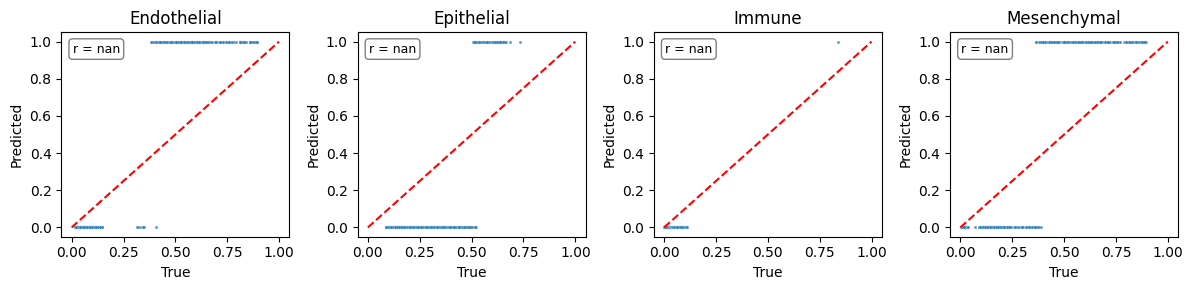

In [131]:
plot_true_vs_predicted(y_test_df=test_czi_cell_prop, predicted_proportions=nnls_pca)

In [86]:
#evaluate_overall_error(y_true_df=test_czi_cell_prop, y_pred_df = nnls_pca)

### GEX

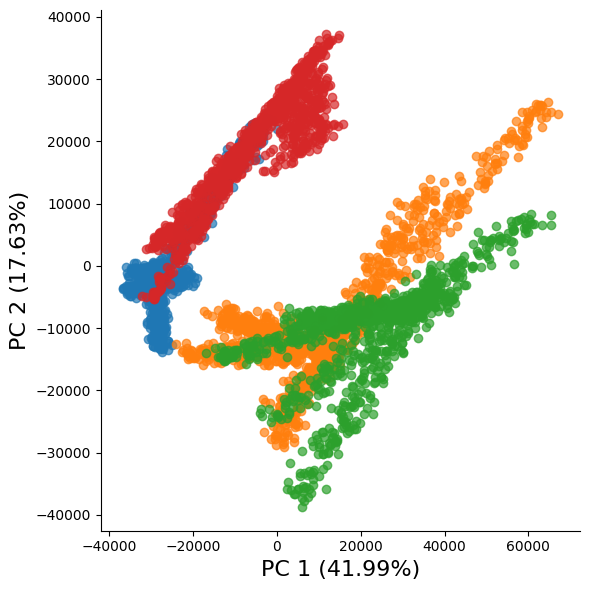

In [36]:
plot_pca(train_df = train_pseudobulk_czi, 
         test_df = test_pseudobulk_czi,
        sample_labels=sample_labels,
        title="GEX",
        save_path="../plots/GEX.png")

In [98]:
# Split into train and test sets
X = train_pseudobulk_czi
y = pseudobulk_czi_cell_prop

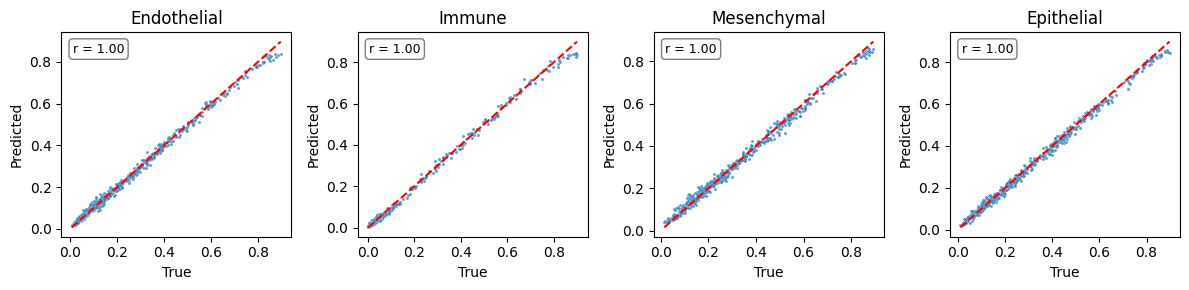

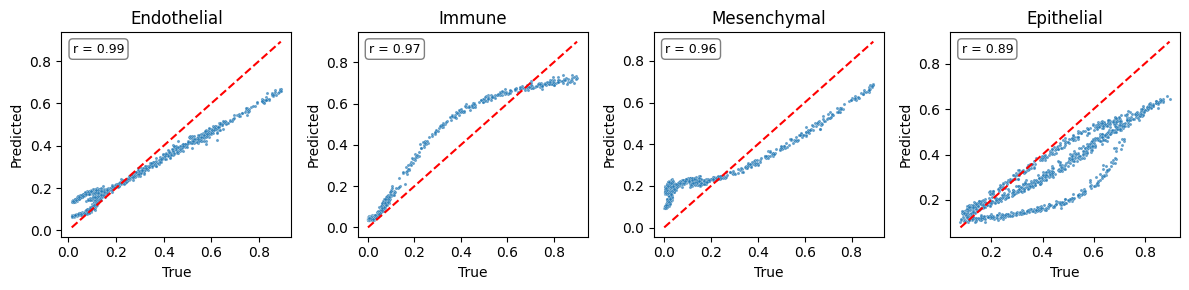

In [99]:
predicted_proportions_valid, predicted_proportions_test = run_rf_training(X = X, 
                                                                          y = y, test = test_pseudobulk_czi)

In [103]:
evaluate_overall_error(y_true_df=test_czi_cell_prop, y_pred_df = predicted_proportions_test)

{'MAE': 0.09235867916264015,
 'MSE': 0.013458719656507918,
 'RMSE': 0.11601172206509099}

### MuSiC

In [110]:
# Read music results
music_deconv = pd.read_csv("/gpfs/commons/groups/compbio/projects/ao_projects/ml_deconv/outputs/music_prop_pseudobulk_czi_vs_czi_single_cell_ref_estimated_heca_lineage_3_train_samples.csv",
                          index_col=0)
music_deconv.reset_index(drop=True, inplace=True)

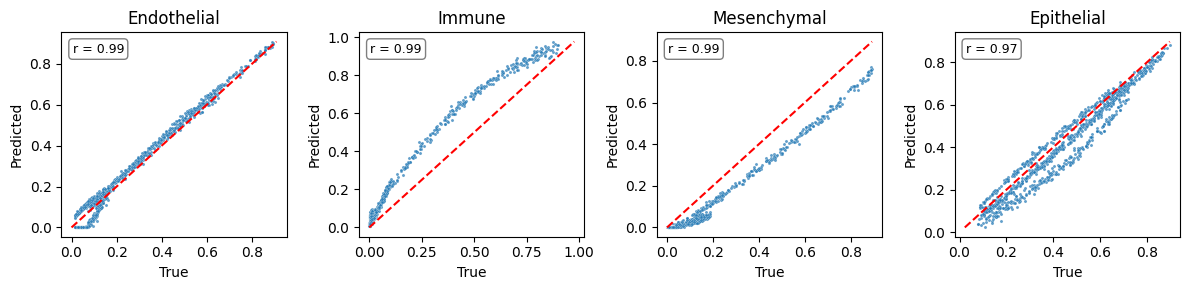

In [111]:
plot_true_vs_predicted(test_czi_cell_prop,music_deconv)

In [112]:
evaluate_overall_error(y_true_df=test_czi_cell_prop, y_pred_df = music_deconv)

{'MAE': 0.053562021962239664,
 'MSE': 0.004892747444931814,
 'RMSE': 0.06994817685209397}